# Parameter Study: PnL and Spread vs Theoretical Worst Case

Three experiments varying one parameter at a time. Each shows:
- **PnL**: violin distribution of realized profits with worst-case loss bound as a floor
- **Spread**: mean bid-ask spread over time with analytic $q=0$ reference

Theoretical worst-case loss bounds (from paper §3.2):
- LMSR: $L_{\max} = b\ln n$
- CFMM ($k=b^n$): $L_{\max} = k^{1/n} = b$

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, '.')
from MarketSim.marketmaker import LMSR, CFMM
from MarketSim.market import Market

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

N_RUNS = 100
T = 500
NOISE_RATIO = 0.5
CONFIDENCE = 0.3

COLOR_LMSR = '#4C72B0'
COLOR_CFMM = '#DD8452'

def make_true_p(n):
    p = np.ones(n) / n
    p[0] += 0.2
    p /= p.sum()
    return p

def analytic_spread(amm, n):
    """Spread for a unit trade on outcome 0 at q=0."""
    r = np.zeros(n)
    r[0] = 1.0
    return amm.get_spread(r)

def run_configs(configs):
    """
    Run N_RUNS simulations for each config dict.
    Each config must have keys: amm_cls, amm_kw, n, label.
    Returns dict: label -> {'pnl': list, 'spreads': 2D array (N_RUNS x T)}
    """
    out = {}
    for cfg in configs:
        true_p = make_true_p(cfg['n'])
        pnl_list = []
        spread_mat = []
        for _ in range(N_RUNS):
            amm = cfg['amm_cls'](cfg['n'], **cfg['amm_kw'])
            market = Market(amm, T, true_p, NOISE_RATIO, agent_confidence=CONFIDENCE)
            price_hist, spread_hist, _, realized = market.run()
            pnl_list.append(realized)
            spread_mat.append(spread_hist)
        out[cfg['label']] = {
            'pnl': np.array(pnl_list),
            'spreads': np.array(spread_mat),  # shape (N_RUNS, T)
            'spread0': analytic_spread(cfg['amm_cls'](cfg['n'], **cfg['amm_kw']), cfg['n']),
            'pnl_floor': cfg.get('pnl_floor', None),
            'color': cfg['color'],
        }
        print(f"  {cfg['label']:40s}  median PnL={np.median(pnl_list):+.2f}  spread0={out[cfg['label']]['spread0']:.4f}")
    return out

def plot_experiment(results, title, fig_name):
    """
    Two-row figure: row 1 = PnL violins, row 2 = spread over time.
    results: ordered list of (label, data_dict, x_pos).
    """
    labels = [r[0] for r in results]
    datas  = [r[1] for r in results]
    x_pos  = [r[2] for r in results]

    fig, axes = plt.subplots(2, 1, figsize=(max(10, len(results)*1.4), 10))

    # ── Row 1: PnL violins ──────────────────────────────────────────────────
    ax = axes[0]
    for lab, dat, xp in results:
        parts = ax.violinplot([dat['pnl']], positions=[xp], widths=0.6,
                              showmedians=True, showextrema=True)
        for body in parts['bodies']:
            body.set_facecolor(dat['color'])
            body.set_alpha(0.55)
        for key in ['cmedians', 'cmins', 'cmaxes', 'cbars']:
            parts[key].set_color(dat['color'])
        if dat['pnl_floor'] is not None:
            ax.hlines(-dat['pnl_floor'], xp - 0.35, xp + 0.35,
                      colors=dat['color'], linestyles='--', lw=2)

    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=20, ha='right')
    ax.set_ylabel('Realized PnL', fontsize=11)
    ax.set_title('PnL Distribution (dashed = worst-case loss bound floor)', fontsize=11)
    ax.grid(True, axis='y', alpha=0.3)

    # ── Row 2: Spread over time ─────────────────────────────────────────────
    ax = axes[1]
    t_axis = np.arange(T)
    for lab, dat, xp in results:
        mean_s = dat['spreads'].mean(axis=0)
        std_s  = dat['spreads'].std(axis=0)
        ax.plot(t_axis, mean_s, color=dat['color'], lw=1.8, label=lab)
        ax.fill_between(t_axis, mean_s - std_s, mean_s + std_s,
                        color=dat['color'], alpha=0.15)
        ax.axhline(dat['spread0'], color=dat['color'], ls='--', lw=1, alpha=0.7)

    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Bid-Ask Spread (outcome 0)', fontsize=11)
    ax.set_title('Mean Spread over Time (dashed = analytic spread at $q=0$)', fontsize=11)
    ax.legend(fontsize=9, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(fig_name, dpi=150, bbox_inches='tight')
    plt.show()

print('Setup complete.')

Setup complete.


## Experiment 1: Vary $n$

Fix $b=50$, $k=b^n$ (normalized so both AMMs start at equal depth). Vary $n \in \{2,4,8,16\}$.

**LMSR bound** $= b\ln n$ grows with $n$. **CFMM bound** $= k^{1/n} = b = 50$ stays constant.

Experiment 1: Vary n
  LMSR n=2                                  median PnL=-4.34  spread0=0.0050
  CFMM n=2                                  median PnL=-4.35  spread0=0.0050
  LMSR n=4                                  median PnL=+4.96  spread0=0.0037
  CFMM n=4                                  median PnL=+2.53  spread0=0.0038
  LMSR n=8                                  median PnL=+2.13  spread0=0.0022
  CFMM n=8                                  median PnL=+0.33  spread0=0.0022
  LMSR n=16                                 median PnL=+0.79  spread0=0.0012
  CFMM n=16                                 median PnL=-0.95  spread0=0.0012


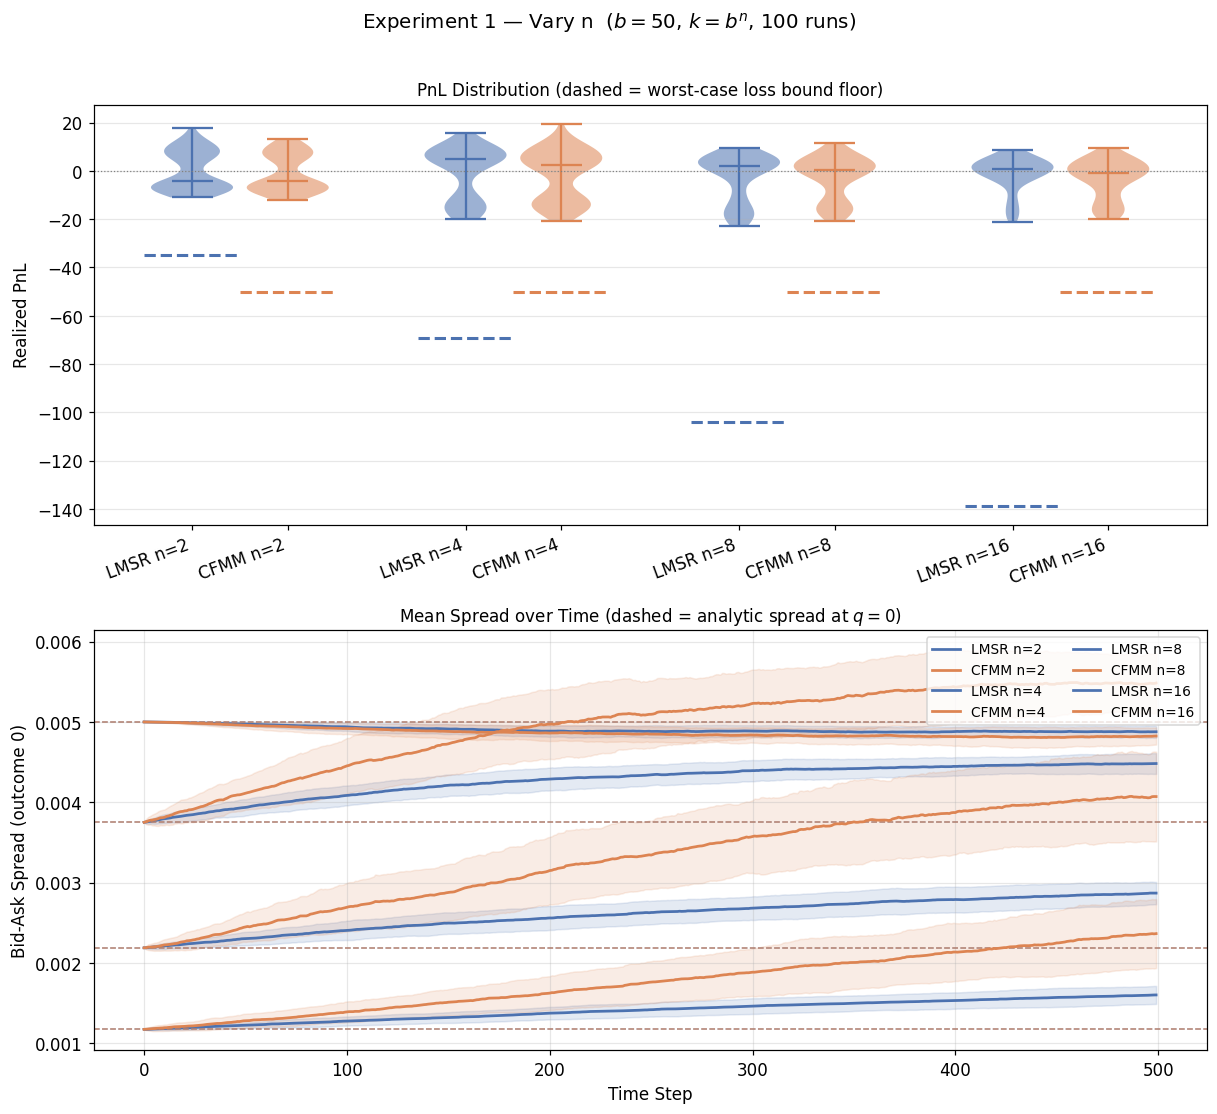

In [2]:
B1 = 50
N_VALS = [2, 4, 8, 16]

print('Experiment 1: Vary n')
configs1 = []
x = 0
for n in N_VALS:
    k = B1 ** n
    configs1.append(dict(
        amm_cls=LMSR, amm_kw={'b': B1}, n=n,
        label=f'LMSR n={n}', color=COLOR_LMSR,
        pnl_floor=B1 * np.log(n)
    ))
    configs1.append(dict(
        amm_cls=CFMM, amm_kw={'k_constant': k}, n=n,
        label=f'CFMM n={n}', color=COLOR_CFMM,
        pnl_floor=float(B1)  # k^(1/n) = b
    ))

raw1 = run_configs(configs1)

# Build ordered results list for plotting
results1 = []
x = 0
for n in N_VALS:
    results1.append((f'LMSR n={n}', raw1[f'LMSR n={n}'], x))
    results1.append((f'CFMM n={n}', raw1[f'CFMM n={n}'], x + 0.7))
    x += 2.0

plot_experiment(results1,
                f'Experiment 1 — Vary n  ($b={B1}$, $k=b^n$, {N_RUNS} runs)',
                'fig_study_vary_n.png')

## Experiment 2: Vary $b$

Fix $n=2$, $k=b^n$ (CFMM adjusts with $b$). Vary $b \in \{10, 25, 50, 100, 200\}$.

Both bounds scale linearly with $b$: LMSR bound $= b\ln 2$, CFMM bound $= b$.

Experiment 2: Vary b
  LMSR b=10                                 median PnL=-0.17  spread0=0.0250
  CFMM b=10                                 median PnL=-0.62  spread0=0.0250
  LMSR b=25                                 median PnL=-2.45  spread0=0.0100
  CFMM b=25                                 median PnL=-2.03  spread0=0.0100
  LMSR b=50                                 median PnL=-6.19  spread0=0.0050
  CFMM b=50                                 median PnL=-5.13  spread0=0.0050
  LMSR b=100                                median PnL=-11.44  spread0=0.0025
  CFMM b=100                                median PnL=-12.03  spread0=0.0025
  LMSR b=200                                median PnL=-18.03  spread0=0.0012
  CFMM b=200                                median PnL=-14.46  spread0=0.0012


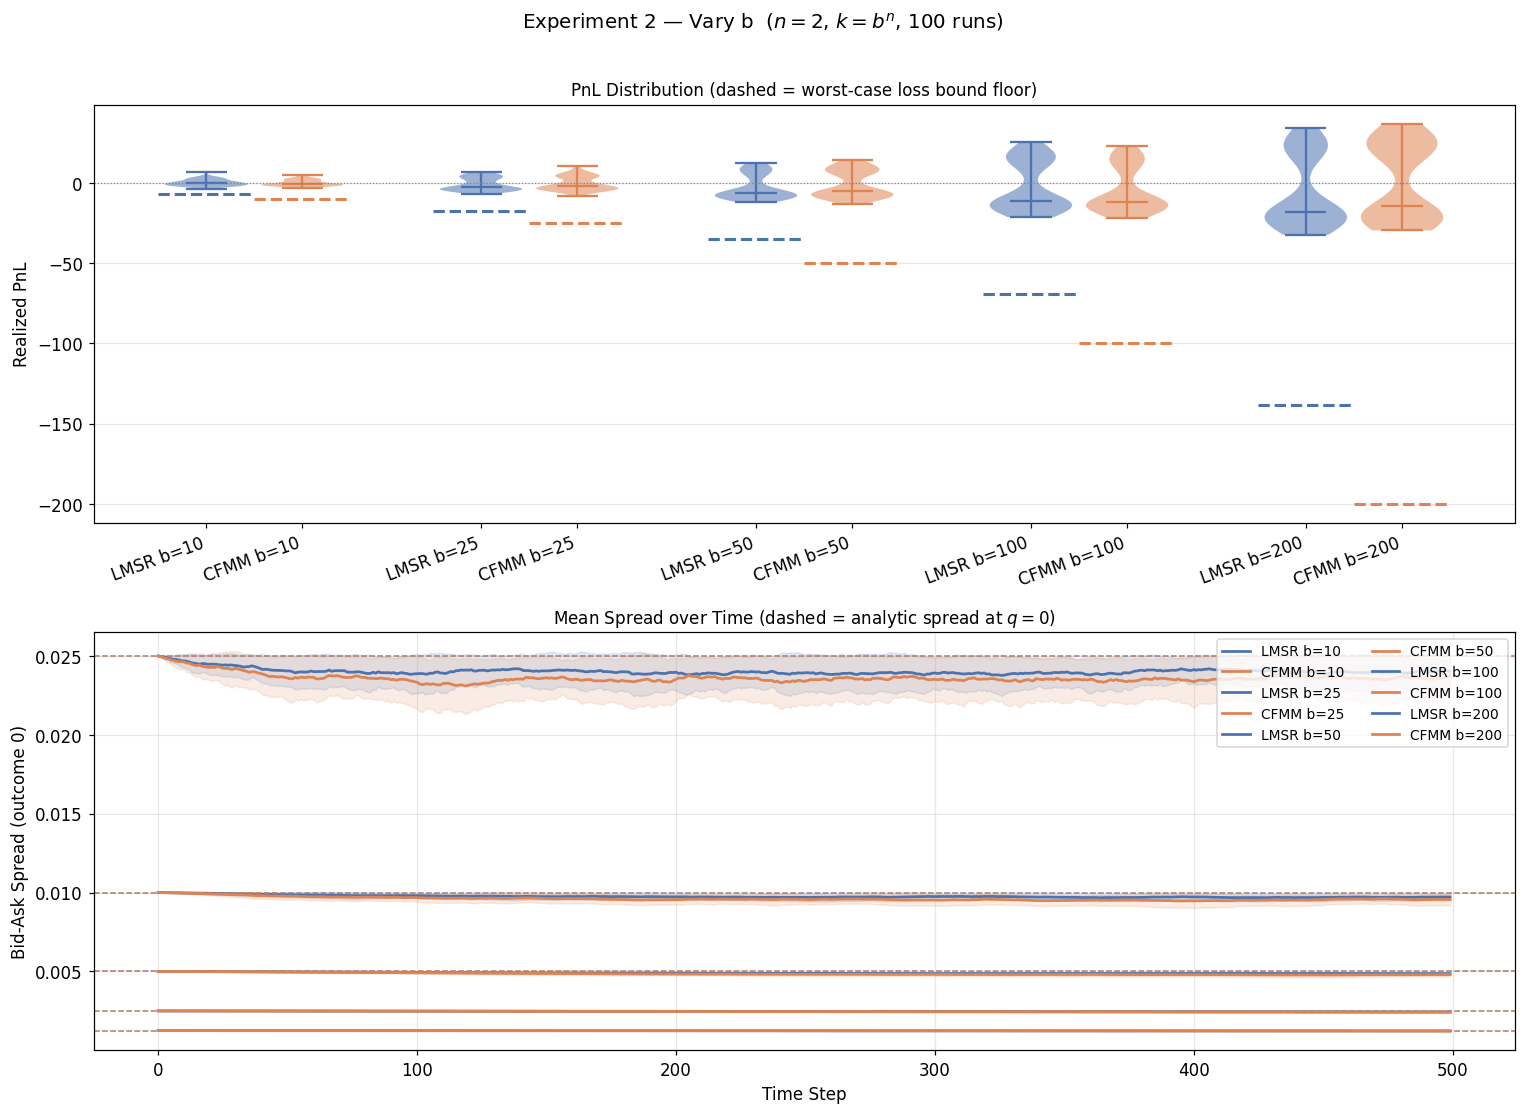

In [3]:
N2 = 2
B_VALS = [10, 25, 50, 100, 200]

print('Experiment 2: Vary b')
configs2 = []
for b in B_VALS:
    k = b ** N2
    configs2.append(dict(
        amm_cls=LMSR, amm_kw={'b': b}, n=N2,
        label=f'LMSR b={b}', color=COLOR_LMSR,
        pnl_floor=b * np.log(N2)
    ))
    configs2.append(dict(
        amm_cls=CFMM, amm_kw={'k_constant': k}, n=N2,
        label=f'CFMM b={b}', color=COLOR_CFMM,
        pnl_floor=float(b)
    ))

raw2 = run_configs(configs2)

results2 = []
x = 0
for b in B_VALS:
    results2.append((f'LMSR b={b}', raw2[f'LMSR b={b}'], x))
    results2.append((f'CFMM b={b}', raw2[f'CFMM b={b}'], x + 0.7))
    x += 2.0

plot_experiment(results2,
                f'Experiment 2 — Vary b  ($n={N2}$, $k=b^n$, {N_RUNS} runs)',
                'fig_study_vary_b.png')

## Experiment 3: Vary $k$ (CFMM only)

Fix $n=2$, $b=50$ (LMSR is unchanged — shown as reference). Vary CFMM $k \in \{100, 500, 2500, 12500, 62500\}$.

CFMM bound $= k^{1/2}$ grows with $k$. Larger $k$ = more liquid = smaller spread but larger loss exposure.

Note: $k=2500=50^2$ is the normalized value used in Experiments 1 and 2.

Experiment 3: Vary k


C:\Users\n8tew\AppData\Local\Temp\ipykernel_11400\1227261424.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cfmm_cmap = plt.cm.get_cmap('YlOrBr', len(K_VALS) + 2)


  LMSR (ref)                                median PnL=-4.45  spread0=0.0050
  CFMM k=100                                median PnL=-0.61  spread0=0.0250
  CFMM k=500                                median PnL=-1.57  spread0=0.0112
  CFMM k=2500                               median PnL=-4.56  spread0=0.0050
  CFMM k=12500                              median PnL=-11.37  spread0=0.0022
  CFMM k=62500                              median PnL=-18.68  spread0=0.0010


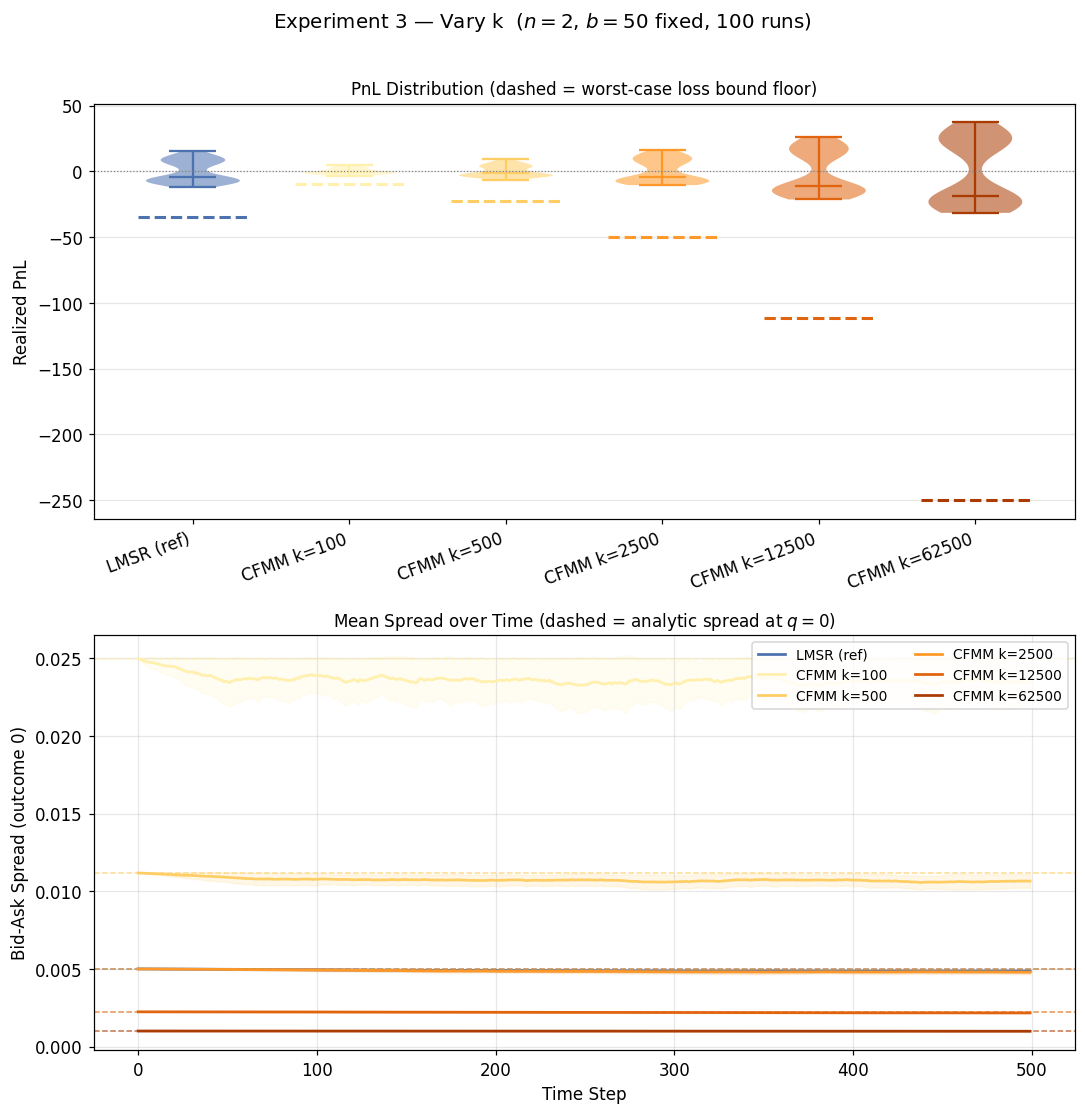


CFMM worst-case bound = k^(1/n):
  k=   100: bound = 10.0
  k=   500: bound = 22.4
  k=  2500: bound = 50.0
  k= 12500: bound = 111.8
  k= 62500: bound = 250.0


In [4]:
N3, B3 = 2, 50
K_VALS = [100, 500, 2500, 12500, 62500]

print('Experiment 3: Vary k')
configs3 = []

# LMSR reference (fixed)
configs3.append(dict(
    amm_cls=LMSR, amm_kw={'b': B3}, n=N3,
    label='LMSR (ref)', color=COLOR_LMSR,
    pnl_floor=B3 * np.log(N3)
))

# CFMM for each k
cfmm_cmap = plt.cm.get_cmap('YlOrBr', len(K_VALS) + 2)
for i, k in enumerate(K_VALS):
    color = cfmm_cmap(i + 1)
    configs3.append(dict(
        amm_cls=CFMM, amm_kw={'k_constant': k}, n=N3,
        label=f'CFMM k={k}', color=color,
        pnl_floor=k ** (1.0 / N3)
    ))

raw3 = run_configs(configs3)

results3 = [(lab, raw3[lab], i) for i, lab in enumerate(['LMSR (ref)'] + [f'CFMM k={k}' for k in K_VALS])]

plot_experiment(results3,
                f'Experiment 3 — Vary k  ($n={N3}$, $b={B3}$ fixed, {N_RUNS} runs)',
                'fig_study_vary_k.png')

print('\nCFMM worst-case bound = k^(1/n):')
for k in K_VALS:
    print(f'  k={k:>6}: bound = {k**0.5:.1f}')